<a href="https://colab.research.google.com/github/rawalnidhi/skin-cancer-xai-ham10000/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAM10000 Skin Cancer Dataset — Exploratory Data Analysis

This notebook performs the initial data setup and exploration for the skin lesion classification project.

The objectives of this stage are:

• Connect to the Kaggle API  
• Download the HAM10000 dataset  
• Verify the dataset structure  
• Inspect metadata and class distribution  
• Visualize sample images and labels  

This step ensures the dataset is correctly loaded before training any machine learning models.

## Kaggle API Setup

The HAM10000 dataset is hosted on Kaggle. To download it programmatically, we use the Kaggle API.

Steps performed:

1. Install the Kaggle Python package.
2. Upload the `kaggle.json` API credential file.
3. Move the credential file to the correct Kaggle configuration directory.
4. Apply proper permissions to ensure secure authentication.

This allows the notebook to securely access datasets directly from Kaggle.

## Upload Kaggle Credentials

The Kaggle API requires a credential file called `kaggle.json`, which contains the user API key.

The file is uploaded manually from the local machine to the Colab runtime.

In [2]:
from google.colab import files
uploaded = files.upload()

# move credential file without printing it
import os
os.makedirs('/root/.kaggle', exist_ok=True)

import shutil
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

!chmod 600 /root/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


## Configure Kaggle Credentials

After uploading the credential file, it must be moved to the `.kaggle` directory inside the runtime environment.

The permission is set to `600` to ensure the key is only readable by the current user.

## Download HAM10000 Dataset

We download the HAM10000 dataset using the Kaggle API.

Dataset source:
https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000

The dataset contains dermatoscopic images of skin lesions categorized into seven diagnostic classes.

In [3]:
!kaggle datasets list -s skin-cancer

ref                                                               title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  ---------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                                 Skin Cancer MNIST: HAM10000                     5582914511  2018-09-20 20:36:13.037000         248473       2261  0.7058824        
nodoubttome/skin-cancer9-classesisic                              Skin Cancer ISIC                                1647873564  2019-08-26 18:59:21.257000          32764        302  0.75             
surajghuwalewala/ham1000-segmentation-and-classification          Skin cancer: HAM10000                           2781385274  2021-05-27 09:08:46.813000          18487        137  0.9411765        
farjanakab

In [4]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:13<00:00, 483MB/s]
100% 5.20G/5.20G [00:13<00:00, 407MB/s]


## Extract Dataset

The downloaded dataset is compressed as a ZIP file. We extract it to access the image folders and metadata file.

In [5]:
!unzip -q skin-cancer-mnist-ham10000.zip

## Verify Dataset Integrity

The dataset should contain two image folders and one metadata file.

Expected structure:

• `HAM10000_images_part_1/`  
• `HAM10000_images_part_2/`  
• `HAM10000_metadata.csv`

We also verify that the total number of images equals **10,015**, which confirms the dataset downloaded correctly.

In [6]:
import os

part1 = "HAM10000_images_part_1"
part2 = "HAM10000_images_part_2"

print("Images in part 1:", len(os.listdir(part1)))
print("Images in part 2:", len(os.listdir(part2)))
print("Total images:", len(os.listdir(part1)) + len(os.listdir(part2)))

Images in part 1: 5000
Images in part 2: 5015
Total images: 10015


The dataset contains **10,015 dermatoscopic images** split into two directories.

• Part 1 contains **5000 images**  
• Part 2 contains **5015 images**

This confirms that the dataset has been downloaded and extracted successfully.

## Metadata Exploration

The HAM10000 dataset includes a metadata file containing important information about each image.

Key columns include:

- **image_id**: Unique identifier for each image
- **dx**: Diagnosis label (skin lesion type)
- **dx_type**: Method used for diagnosis
- **age**: Age of the patient
- **sex**: Gender of the patient
- **localization**: Body location of the lesion

Understanding this metadata helps us analyze dataset characteristics before training models.

In [7]:
import pandas as pd

# Load metadata file
metadata = pd.read_csv("HAM10000_metadata.csv")

# Display first few rows
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Skin Lesion Classes

The HAM10000 dataset contains **seven diagnostic categories**:

| Label | Meaning |
|------|------|
| akiec | Actinic keratoses |
| bcc | Basal cell carcinoma |
| bkl | Benign keratosis-like lesions |
| df | Dermatofibroma |
| nv | Melanocytic nevi (moles) |
| mel | Melanoma |
| vasc | Vascular lesions |

Some of these classes represent **benign lesions**, while others are **malignant skin cancers**.  
This makes the dataset suitable for building deep learning models for **skin cancer detection and classification**.

In [8]:
print("Metadata shape:", metadata.shape)
print("\nColumns:", metadata.columns)

Metadata shape: (10015, 7)

Columns: Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')


## Class Distribution

Before training models, it is important to check whether the dataset is **balanced**.

Class imbalance can affect model performance, especially for medical datasets where rare diseases may have fewer examples.

We visualize the distribution of the diagnosis labels.

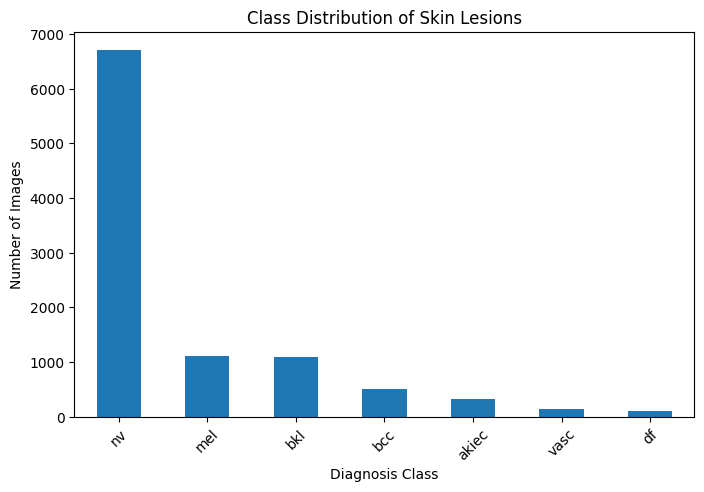

In [9]:
import matplotlib.pyplot as plt

class_counts = metadata['dx'].value_counts()

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')

plt.title("Class Distribution of Skin Lesions")
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

### Observations

The dataset is **highly imbalanced**.

The class **nv (melanocytic nevi)** contains the majority of images, while classes such as **df** and **vasc** have very few samples.

Class imbalance is common in medical datasets and must be addressed during model training.  
Possible strategies include:

- Data augmentation
- Class weighting
- Oversampling minority classes

## Sample Image Visualization

To understand the visual characteristics of the dataset, we display several random images along with their corresponding diagnosis labels.

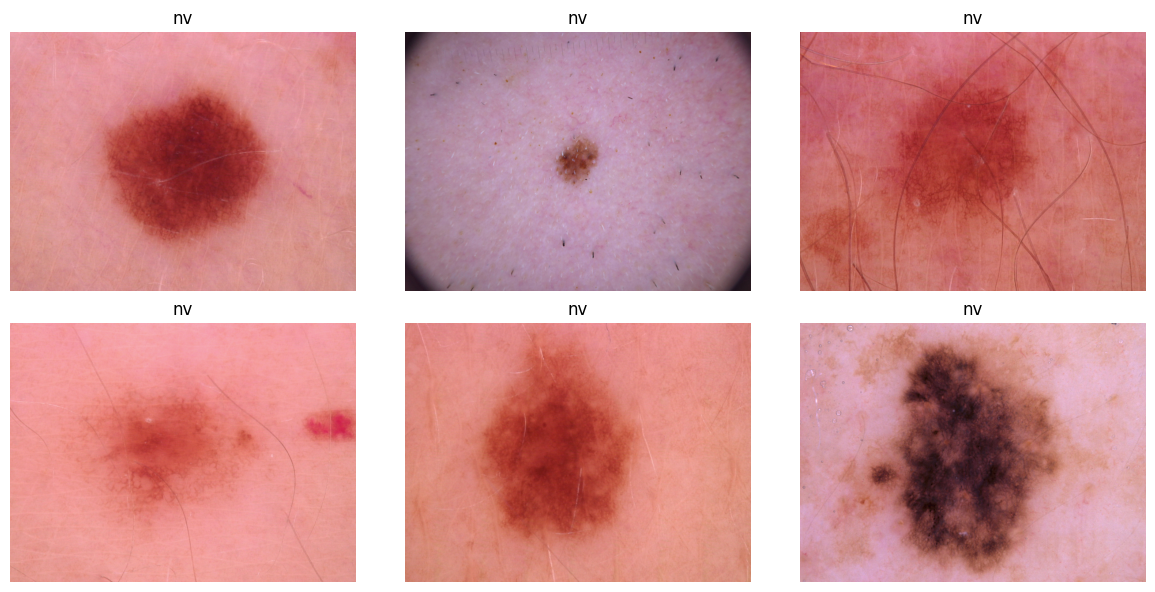

In [10]:
import random
from PIL import Image
import os

image_folder_1 = "HAM10000_images_part_1"
image_folder_2 = "HAM10000_images_part_2"

def get_image_path(image_id):
    path1 = os.path.join(image_folder_1, image_id + ".jpg")
    path2 = os.path.join(image_folder_2, image_id + ".jpg")
    return path1 if os.path.exists(path1) else path2

sample_images = metadata.sample(6)

plt.figure(figsize=(12,6))

for i, row in enumerate(sample_images.itertuples(), 1):
    img_path = get_image_path(row.image_id)
    img = Image.open(img_path)

    plt.subplot(2,3,i)
    plt.imshow(img)
    plt.title(row.dx)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Patient Demographics

We also explore the distribution of patient age and gender within the dataset.

This can reveal potential biases in the data.

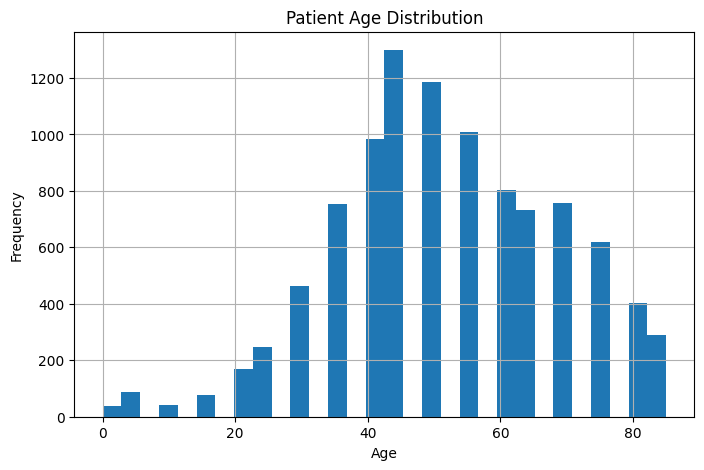

In [11]:
plt.figure(figsize=(8,5))

metadata['age'].hist(bins=30)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

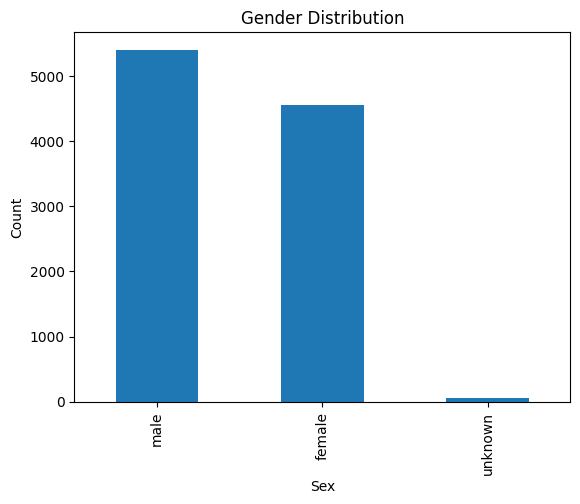

In [12]:
metadata['sex'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

## Diagnosis Method Analysis

The `dx_type` column indicates how the diagnosis was confirmed.

Common values include:

- **histo** — histopathology (most reliable)
- **follow_up** — monitored over time
- **consensus** — expert agreement
- **confocal** — confocal microscopy

Understanding the diagnosis method helps assess the reliability of labels in the dataset.

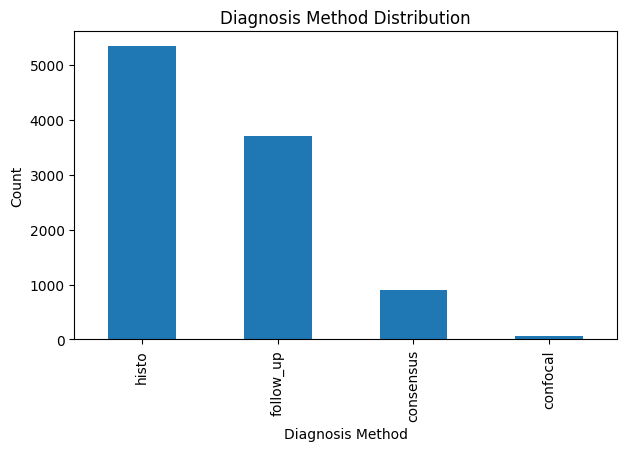

In [13]:
plt.figure(figsize=(7,4))

metadata['dx_type'].value_counts().plot(kind='bar')

plt.title("Diagnosis Method Distribution")
plt.xlabel("Diagnosis Method")
plt.ylabel("Count")

plt.show()

## Lesion Body Location Distribution

The `localization` column indicates where on the body the lesion appears.

Analyzing body location helps understand where skin lesions most commonly occur.

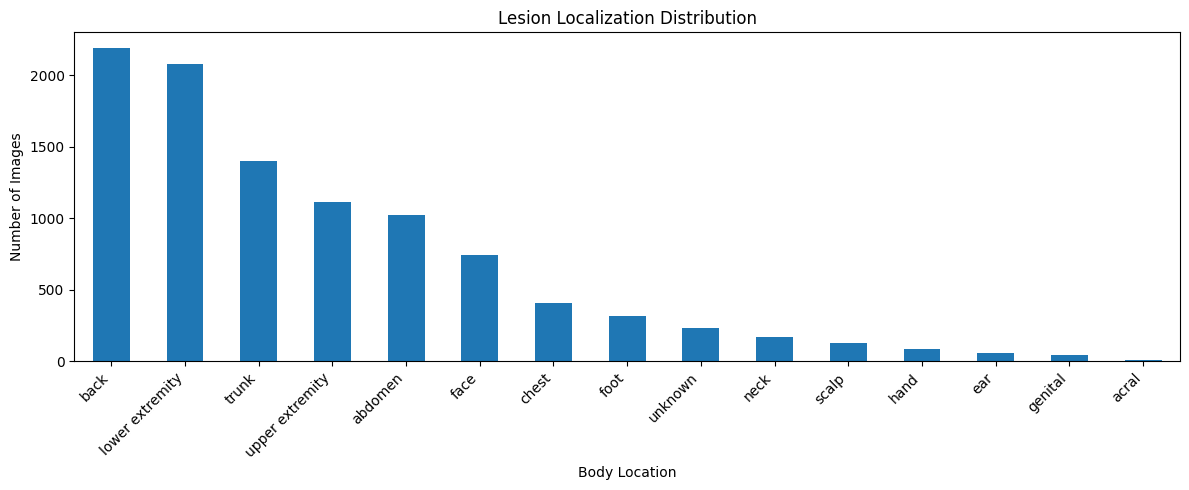

In [14]:
loc_counts = metadata['localization'].value_counts()

plt.figure(figsize=(12,5))

loc_counts.plot(kind='bar')

plt.title("Lesion Localization Distribution")
plt.xlabel("Body Location")
plt.ylabel("Number of Images")

plt.xticks(range(len(loc_counts.index)), loc_counts.index, rotation=45, ha='right')

plt.tight_layout()

plt.show()

### Observations

Skin lesions appear most frequently on the **back**, **lower extremities**, and **trunk**.

This distribution may reflect areas of the body that receive higher sun exposure or are commonly examined during dermatological screening.

Understanding lesion localization can help contextualize the dataset and identify potential biases in image collection.

## Missing Data Analysis

Before training machine learning models, it is important to check for missing values in the dataset.

Missing values may require preprocessing or imputation.

In [15]:
metadata.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


### Observations

The dataset contains a small number of missing values, in the **age** column.

Since age is not used directly for image classification, these missing values will not significantly affect the training of the CNN model.

## Key Insights from EDA

• The dataset contains **10,015 dermatoscopic images** across **7 diagnostic categories**.

• The dataset is **highly imbalanced**, with the **melanocytic nevi (nv)** class dominating the dataset.

• Most diagnoses are confirmed using **histopathology**, which suggests reliable labeling.

• Skin lesions appear most frequently on the **back, lower extremities, and trunk**.

• Patient ages are primarily concentrated between **40 and 70 years**, consistent with dermatology studies.

These observations will inform preprocessing strategies and model training in subsequent stages of the project.